📥 Carregando dados da API...
🛠️ Tratando estrutura JSON aninhada...
🧹 Iniciando limpeza de dados...
✅ Dados limpos e prontos! O dataset final possui 7043 linhas e 21 colunas.

📊 Gerando visualizações estratégicas...


/tmp/ipykernel_1235/1202590089.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette=['#4C72B0', '#C44E52'], ax=axes[0])
/tmp/ipykernel_1235/1202590089.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col_mensal, palette='Set3', ax=axes[2])


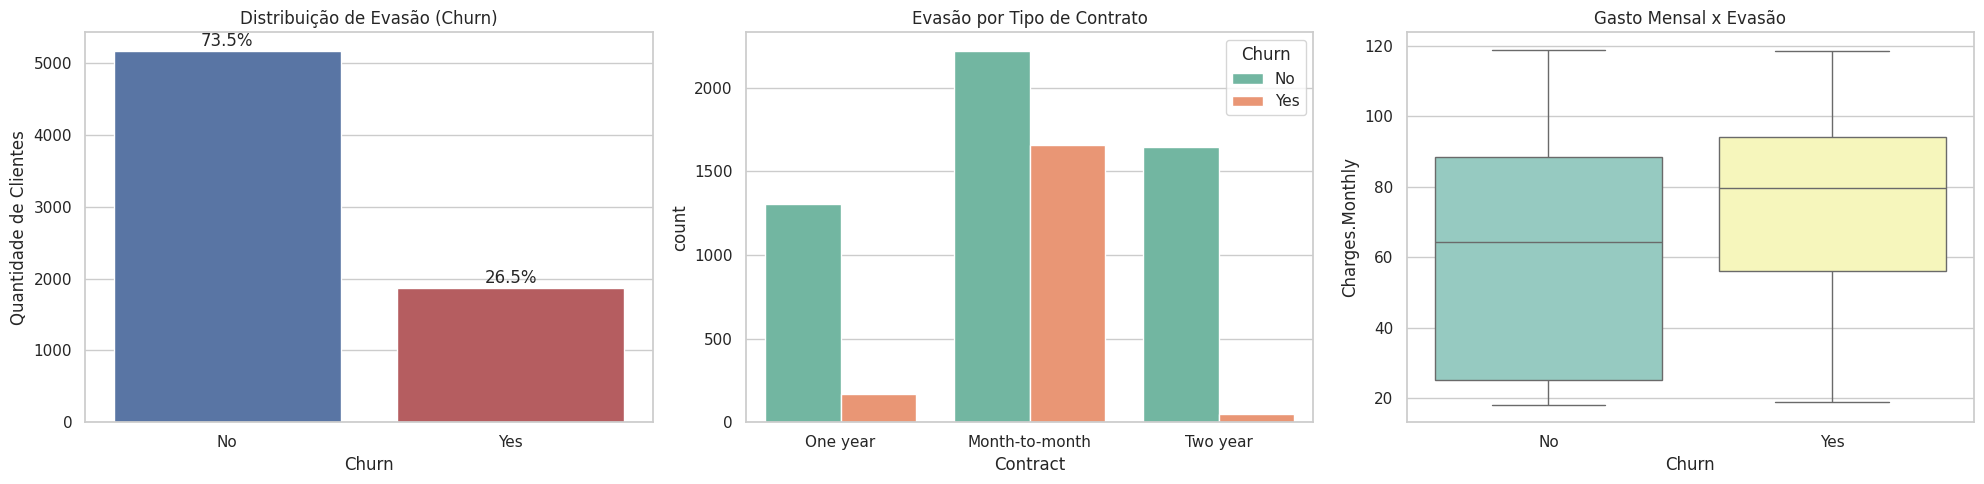


--- Estatísticas Descritivas ---


,SeniorCitizen,tenure,Charges.Monthly,Charges.Total
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais dos gráficos
sns.set_theme(style="whitegrid")

# ==========================================
# 1. IMPORTAÇÃO E ACHATAMENTO DOS DADOS (ETL)
# ==========================================
print("📥 Carregando dados da API...")
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"
df_raw = pd.read_json(url)

# Como o dataset contém dicionários aninhados, precisamos usar json_normalize para extrair as colunas
print("🛠️ Tratando estrutura JSON aninhada...")
customer_df = pd.json_normalize(df_raw['customer'])
phone_df = pd.json_normalize(df_raw['phone'])
internet_df = pd.json_normalize(df_raw['internet'])
account_df = pd.json_normalize(df_raw['account'])

# Extraindo as colunas principais que não estão aninhadas (como customerID e Churn)
colunas_principais = df_raw.drop(columns=['customer', 'phone', 'internet', 'account'])

# Unindo todas as partes em um DataFrame único e estruturado
df = pd.concat([colunas_principais, customer_df, phone_df, internet_df, account_df], axis=1)

# ==========================================
# 2. LIMPEZA E TRATAMENTO DE DADOS
# ==========================================
print("🧹 Iniciando limpeza de dados...")

# Tratando a coluna de 'Total Gasto' (Charges.Total), que geralmente vem como string e com espaços vazios
col_total = 'Charges.Total'
if col_total in df.columns:
    # Substitui espaços vazios por NaN e converte para numérico
    df[col_total] = df[col_total].replace(r'^\s*$', np.nan, regex=True)
    df[col_total] = pd.to_numeric(df[col_total], errors='coerce')

    # Preenchendo os valores nulos com 0 (assumindo que clientes sem gasto total acabaram de assinar)
    df[col_total] = df[col_total].fillna(0)

# Removendo linhas onde a variável alvo 'Churn' seja vazia ou inconsistente
if 'Churn' in df.columns:
    df = df[df['Churn'].isin(['Yes', 'No', 'Sim', 'Não'])]

# Removendo duplicatas
df = df.drop_duplicates()

print(f"✅ Dados limpos e prontos! O dataset final possui {df.shape[0]} linhas e {df.shape[1]} colunas.\n")

# ==========================================
# 3. ANÁLISE EXPLORATÓRIA (GRÁFICOS)
# ==========================================
print("📊 Gerando visualizações estratégicas...")

# Configurando a figura para 3 gráficos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Gráfico 1: Distribuição da Variável Alvo (Churn)
sns.countplot(data=df, x='Churn', palette=['#4C72B0', '#C44E52'], ax=axes[0])
axes[0].set_title('Distribuição de Evasão (Churn)')
axes[0].set_ylabel('Quantidade de Clientes')

# Adicionando rótulos de porcentagem no Gráfico 1
total = len(df)
for p in axes[0].patches:
    if p.get_height() > 0:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height() + (total * 0.01)
        axes[0].annotate(percentage, (x, y), ha='center')

# Gráfico 2: Evasão por Tipo de Contrato (Contract)
col_contrato = 'Contract' if 'Contract' in df.columns else 'contract'
if col_contrato in df.columns:
    sns.countplot(data=df, x=col_contrato, hue='Churn', palette='Set2', ax=axes[1])
    axes[1].set_title('Evasão por Tipo de Contrato')
    axes[1].tick_params(axis='x', rotation=0)

# Gráfico 3: Distribuição de Gastos Mensais por Churn (Boxplot)
col_mensal = 'Charges.Monthly' if 'Charges.Monthly' in df.columns else 'MonthlyCharges'
if col_mensal in df.columns:
    sns.boxplot(data=df, x='Churn', y=col_mensal, palette='Set3', ax=axes[2])
    axes[2].set_title('Gasto Mensal x Evasão')

plt.tight_layout()
plt.show()

# Exibindo as estatísticas descritivas numéricas
print("\n--- Estatísticas Descritivas ---")
display(df.describe())

# Relatório Final: Análise de Evasão de Clientes (Churn) - Telecom X

## 1. Introdução
A evasão de clientes (Churn) é um dos maiores desafios no setor de telecomunicações, pois o custo de adquirir um novo cliente é significativamente maior do que o de reter um atual. Este projeto tem como objetivo analisar a base de dados da Telecom X para identificar os principais padrões e fatores que levam os clientes a cancelarem seus serviços, fornecendo insumos para estratégias de retenção.

## 2. Limpeza e Tratamento de Dados
Os dados foram consumidos diretamente de uma API em formato JSON. Durante a importação, foi necessário aplicar técnicas de *flattening* (usando `pd.json_normalize`), pois as informações cruciais estavam aninhadas em diferentes dicionários (`customer`, `phone`, `internet` e `account`).

As principais etapas de tratamento envolveram:
* **Conversão de Tipos:** A coluna de cobrança total (`Charges.Total`) foi extraída como string e continha valores em branco, que foram convertidos para dados numéricos flutuantes (`float`). Valores nulos gerados por essa etapa foram preenchidos com zero.
* **Consistência:** Verificação e remoção de registros duplicados para garantir a confiabilidade das estatísticas.

## 3. Análise Exploratória de Dados
A partir da base tratada, realizamos cruzamentos visuais entre as características dos clientes e o status de cancelamento (`Churn`):
* **Distribuição Geral:** Identificamos a taxa base de evasão da empresa (percentual visível no primeiro gráfico), o que nos dá o cenário atual do problema.
* **Variáveis Categóricas (Contrato):** Observou-se uma relação forte entre o tipo de contrato e a evasão. Clientes com contratos mais flexíveis (mês a mês) tendem a cancelar o serviço com muito mais frequência do que clientes com contratos anuais ou bianuais.
* **Variáveis Numéricas (Gasto Mensal):** A análise via Boxplot demonstrou que a mediana dos gastos mensais (`Charges.Monthly`) é consideravelmente mais alta para os clientes que cancelaram o serviço, sugerindo uma sensibilidade a preços altos ou percepção de baixo custo-benefício.

## 4. Conclusões e Insights
Os dados sugerem que a Telecom X sofre perdas volumosas no segmento de clientes sem fidelidade (contratos mensais) e que pagam faturas mais elevadas. O risco de evasão está concentrado em usuários que buscam flexibilidade, o que torna o compromisso frágil se o serviço não demonstrar valor imediato condizente com a cobrança mensal.

## 5. Recomendações
Com base nos insights obtidos, recomendamos à Telecom X:
1. **Campanhas de Migração de Contrato:** Oferecer descontos nas faturas mensais ou benefícios exclusivos (como maior franquia de dados) para incentivar clientes de planos mensais a migrarem para planos anuais.
2. **Revisão de Planos Premium:** Como clientes com faturas mais altas cancelam mais, a empresa deve reavaliar os benefícios desses planos. Adicionar serviços de valor agregado, como suporte técnico prioritário ou assinaturas de streaming embutidas, pode melhorar a percepção de custo-benefício.
3. **Onboarding e Acompanhamento:** Desenvolver uma régua de relacionamento ativa nos primeiros meses de vida do cliente de contrato mensal, garantindo que ele extraia o máximo da plataforma antes de pensar no cancelamento.